# EDA & DAG Validation
- Research question: How SME composition, economic resilience, and employment shape local labour productivity in Swindon.

- Causal chain (DAG): Policy -> Business Size Structure -> Economic Resilience -> Employment Rate -> GVA.

- This is an explanatory study: features are chosen by the DAG nodes, not by an algorithm.

- Target is log GVA per worker (labour productivity)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
short = lambda c: c[:32]
target = "log_gva_per_worker"
def winsorize(frame, cols, bounds=None, lo=0.01, hi=0.99):
    out = frame.copy()
    if bounds is None:
        bounds = {c: (out[c].quantile(lo), out[c].quantile(hi)) for c in cols}
    for c in cols:
        out[c] = out[c].clip(*bounds[c])
    return out, bounds
# EDA uses the training set only
df = pd.read_csv("train.csv")
df["is_swindon"] = np.where(
    df["LSOA21NM"].str.replace(r"\s\d.*", "", regex=True).eq("Swindon"),
    "Swindon", "Others")
num_feats = df.select_dtypes("number").columns.tolist()
dag_num = [c for c in num_feats if c not in (target, "log_LSOA GVA Estimates (millions)", "Urban_rura_Urban")]
df, _ = winsorize(df, num_feats)

## 1. Bivariate analysis - validate the causal chain step by step

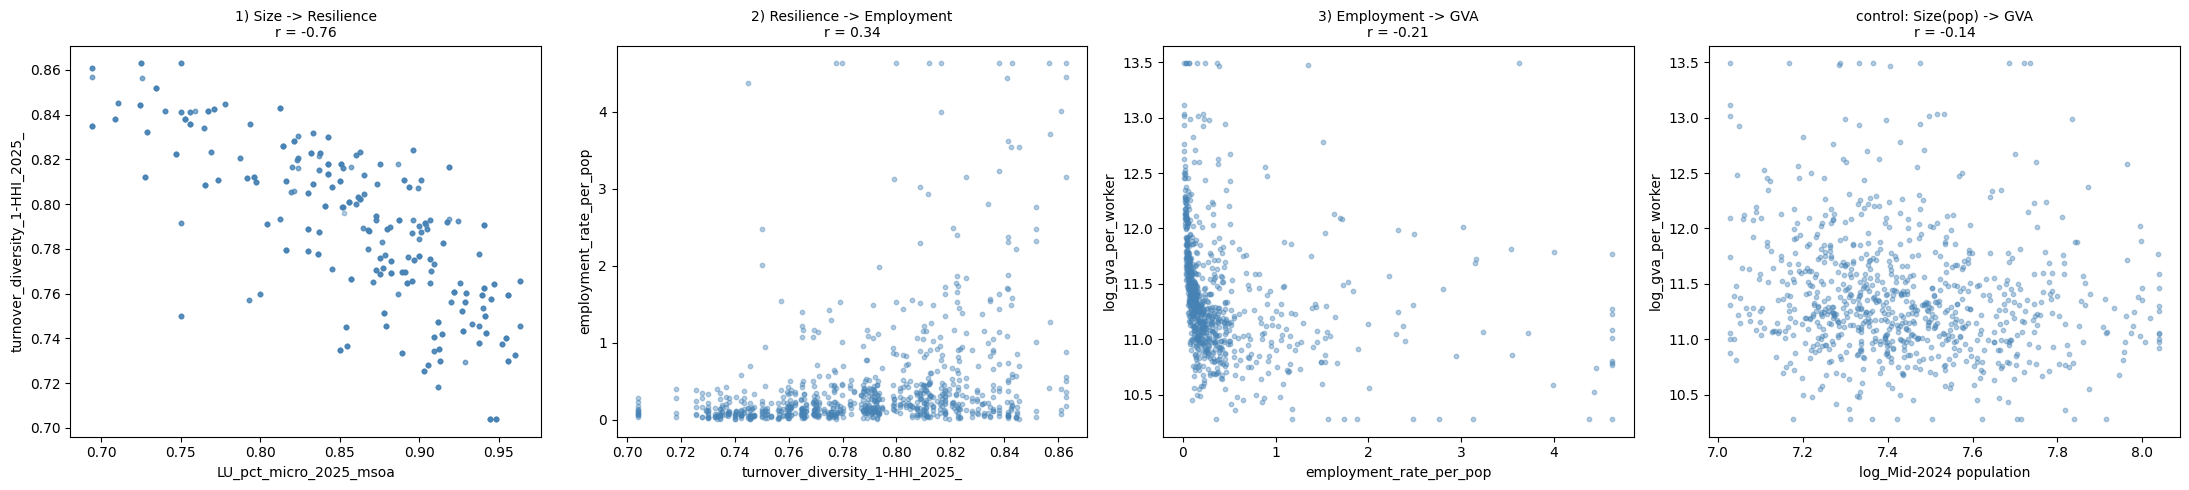

In [2]:
steps = [
    ("LU_pct_micro_2025_msoa", "turnover_diversity_1-HHI_2025_msoa", "1) Size -> Resilience"),
    ("turnover_diversity_1-HHI_2025_msoa", "employment_rate_per_pop", "2) Resilience -> Employment"),
    ("employment_rate_per_pop", target, "3) Employment -> GVA"),
    ("log_Mid-2024 population", target, "control: Size(pop) -> GVA"),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (x, y, title) in zip(axes, steps):
    ax.scatter(df[x], df[y], s=10, alpha=0.4, color="steelblue")
    ax.set_xlabel(x[:30]); ax.set_ylabel(y[:30])
    ax.set_title(f"{title}\nr = {df[x].corr(df[y]):.2f}", fontsize=10)
plt.tight_layout()
plt.show()

## 2. Collinearity check

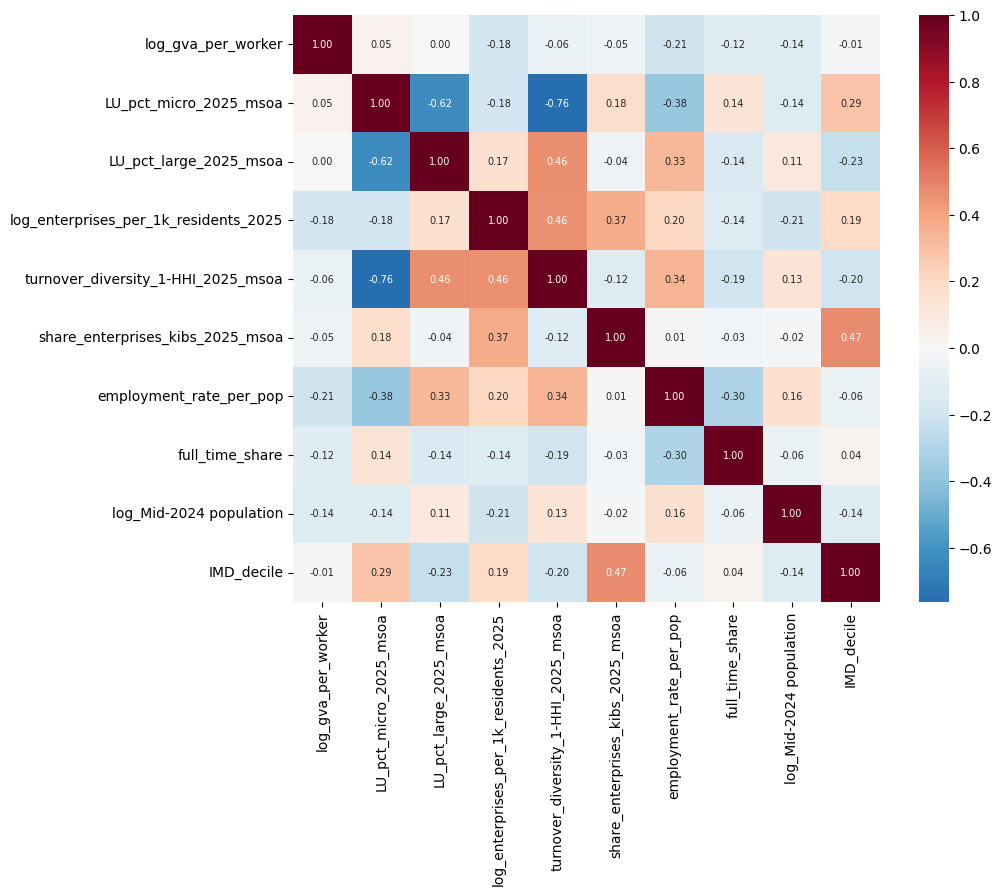

In [3]:
node_vars = [target] + dag_num
corr = df[node_vars].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, annot_kws={"size": 7})
plt.tight_layout()
plt.show()

## 3. Group comparison (urban/rural and Swindon vs others)

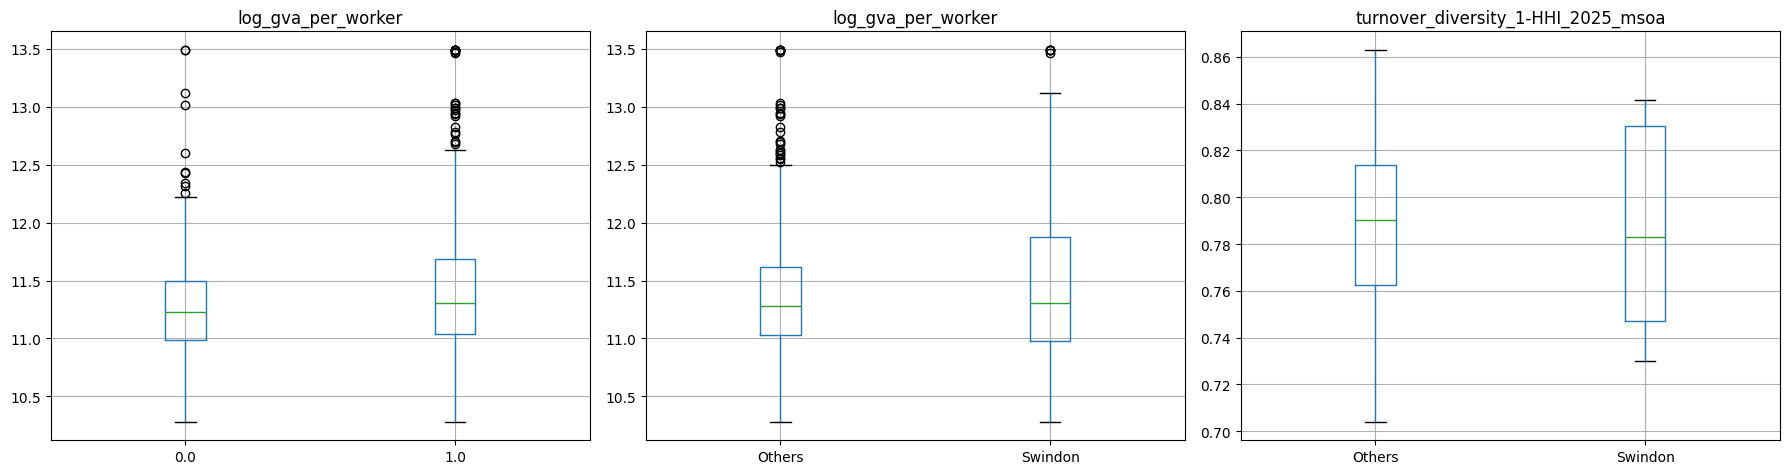

is_swindon                                    Others    Swindon
log_gva_per_worker                 mean    11.367854  11.485131
                                   median  11.278517  11.304156
LU_pct_micro_2025_msoa             mean     0.862120   0.842947
                                   median   0.872549   0.857143
turnover_diversity_1-HHI_2025_msoa mean     0.788718   0.787026
                                   median   0.790400   0.783208
employment_rate_per_pop            mean     0.452468   0.500903
                                   median   0.205895   0.144676
full_time_share                    mean     0.340419   0.372157
                                   median   0.333333   0.375000


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
df.boxplot(column=target, by="Urban_rura_Urban", ax=axes[0])
df.boxplot(column=target, by="is_swindon", ax=axes[1])
df.boxplot(column="turnover_diversity_1-HHI_2025_msoa", by="is_swindon", ax=axes[2])
for ax in axes:
    ax.set_xlabel(""); plt.suptitle("")
plt.tight_layout()
plt.show()

print(df.groupby("is_swindon")[[
    target, "LU_pct_micro_2025_msoa",
    "turnover_diversity_1-HHI_2025_msoa", "employment_rate_per_pop", "full_time_share",
]].agg(["mean", "median"]).T)

## 4. Spatial analysis (map + spatial clustering)

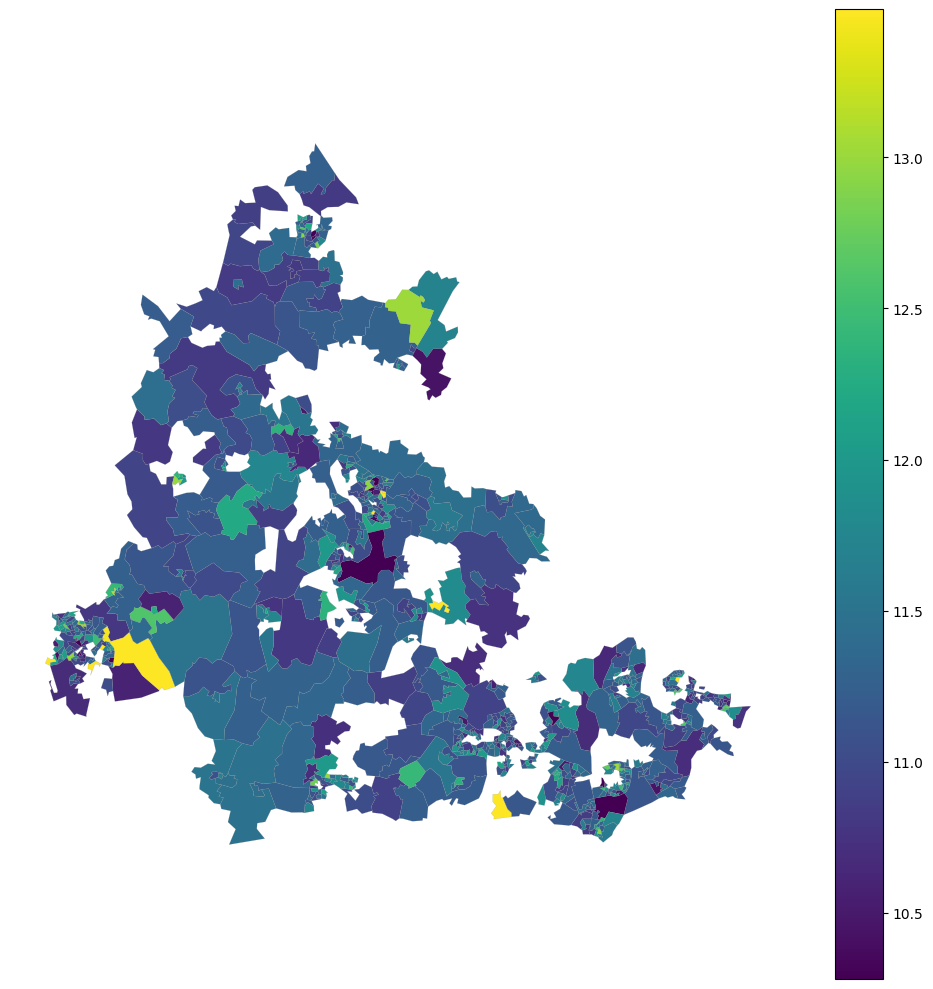

In [5]:
import geopandas as gpd
gdf = gpd.read_file("LSOA_boundaries.geojson").merge(df, on="LSOA21CD")
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(column=target, cmap="viridis", legend=True, ax=ax, linewidth=0.1, edgecolor="grey")
ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
from libpysal.weights import KNN
from esda.moran import Moran
g = gdf.dropna(subset=[target]).reset_index(drop=True)
w = KNN.from_dataframe(g, k=6); w.transform = "r"
mi = Moran(g[target], w)
print("Moran's I (KNN):", round(mi.I, 3), "p:", round(mi.p_sim, 3))

Moran's I (KNN): 0.076 p: 0.002


D:\MYAPP\python3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 5. Within-node redundancy - VIF on the DAG numeric features

In [7]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
Xv = sm.add_constant(df[dag_num].dropna())
vif = pd.Series([variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])],
                index=Xv.columns).drop("const").sort_values(ascending=False)
print(vif.round(2))
print("All VIF < 10:", bool((vif < 10).all()))

turnover_diversity_1-HHI_2025_msoa       3.61
LU_pct_micro_2025_msoa                   3.52
log_enterprises_per_1k_residents_2025    2.05
LU_pct_large_2025_msoa                   1.72
share_enterprises_kibs_2025_msoa         1.61
IMD_decile                               1.42
employment_rate_per_pop                  1.32
log_Mid-2024 population                  1.20
full_time_share                          1.12
dtype: float64
All VIF < 10: True


## 6. Distributions of the selected features

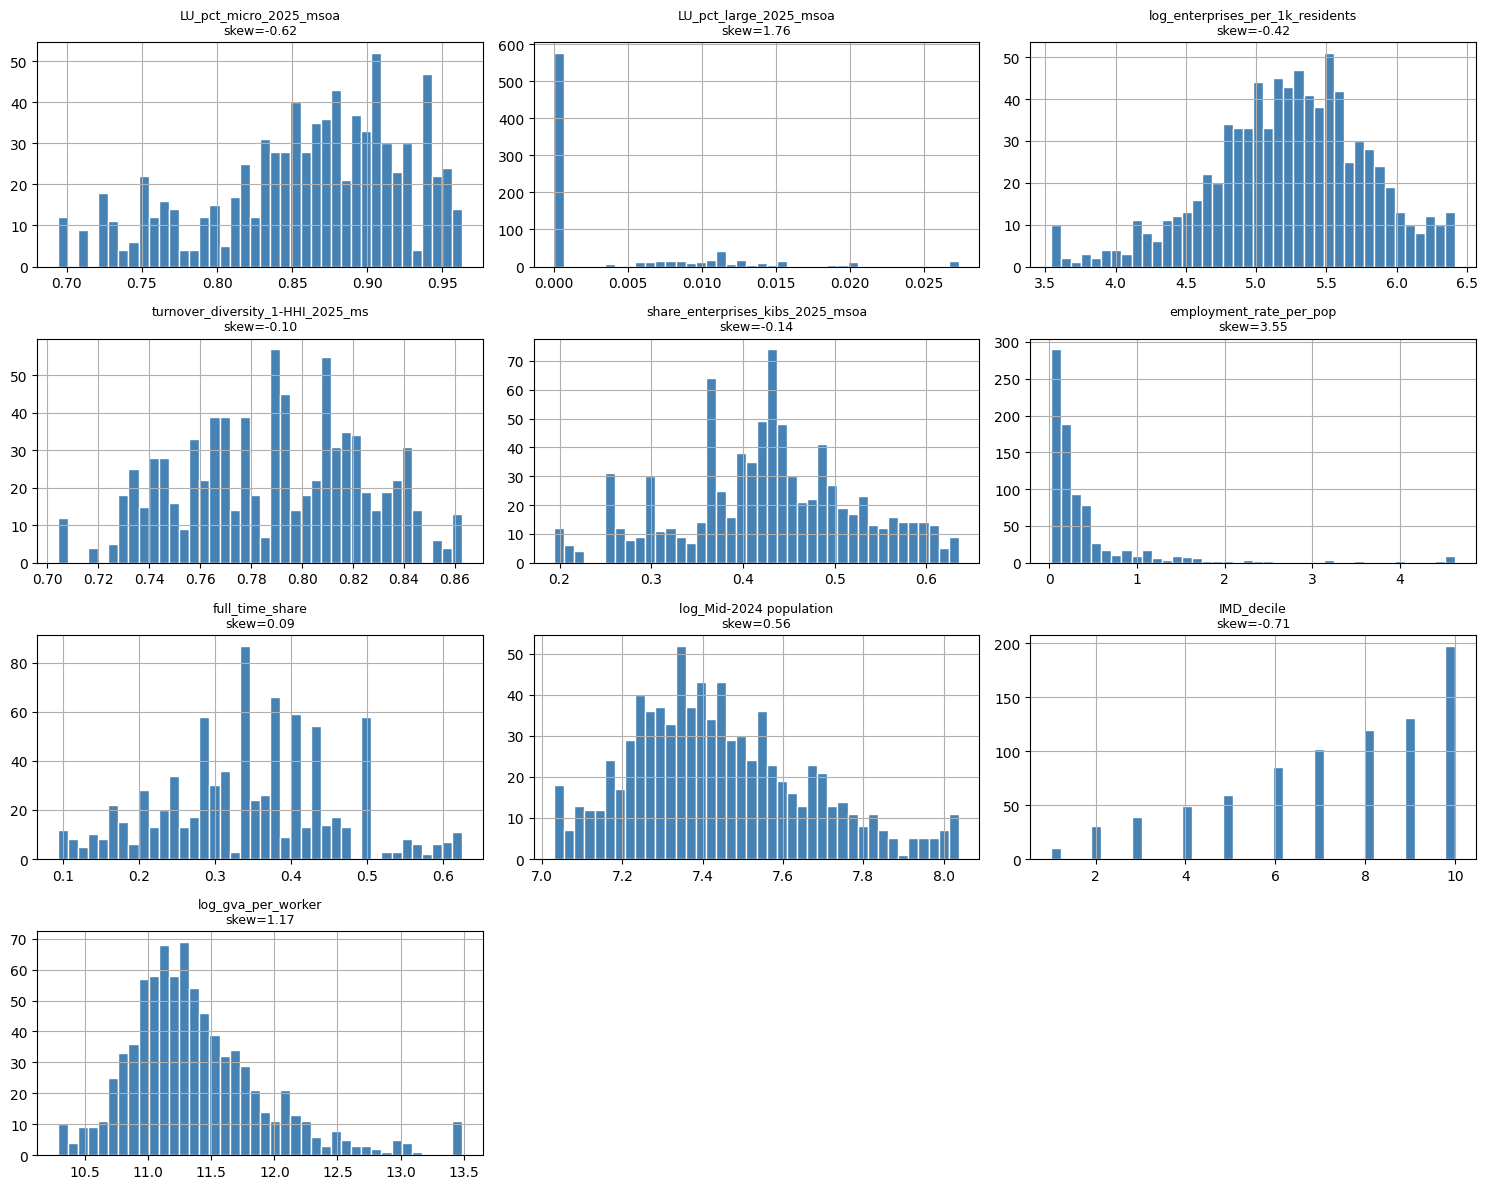

In [8]:
key = dag_num + [target]
cols = 3
rows = (len(key) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
for ax, c in zip(axes.flat, key):
    df[c].hist(bins=40, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"{short(c)}\nskew={df[c].skew():.2f}", fontsize=9)
for ax in axes.flat[len(key):]:
    ax.axis("off")
plt.tight_layout()
plt.show()